<a href="https://colab.research.google.com/github/fergogu27-ctrl/EDPII/blob/main/Algoritmo_Metropolis_2D_corregido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MCMC. Algoritmo de Metropolis**



Implementar desde cero el **algoritmo de Metropolis** para generar una cadena de Markov cuya distribución estacionaria sea proporcional a una función objetivo bidimensional.

La función de prueba vista en clase es

$$
\boxed{f(x,y)=c\exp\left[-\frac{1}{2}\left(x^2y^2+x^2+y^2-8x-8y\right)\right]}
$$

donde $c$ es la constante de normalización.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Función objetivo

Para simplificar la notación definimos
$$H(x,y)=x^2y^2+x^2+y^2-8x-8y$$

Entonces
$$f(x,y)\propto e^{-H(x,y)/2}$$

Es conveniente trabajar también con el **logaritmo de la función objetivo**:
$$\log \pi(x,y)=-\frac{1}{2}H(x,y)$$

porque así evitamos problemas numéricos al dividir números muy pequeños.


In [2]:
def H(x, y):
    # Función H(x,y) que aparece en el exponente
    return x**2 * y**2 + x**2 + y**2 - 8*x - 8*y


def log_pi(x, y):
    # Logaritmo de la densidad objetivo, salvo una constante aditiva
    return -0.5 * H(x, y)


def pi_no_normalizada(x, y):
    # Función objetivo sin la constante de normalización c
    return np.exp(log_pi(x, y))

## 3. Visualización de la función bidimensional

Antes de aplicar Metropolis conviene observar la forma de la función objetivo.

Se construye una malla rectangular con `np.meshgrid`. Para cada punto \((x,y)\) de esa malla se evalúa la función no normalizada.

La gráfica de contornos permite identificar las regiones donde la función toma valores altos; ésas serán las regiones que la cadena deberá visitar con mayor frecuencia.

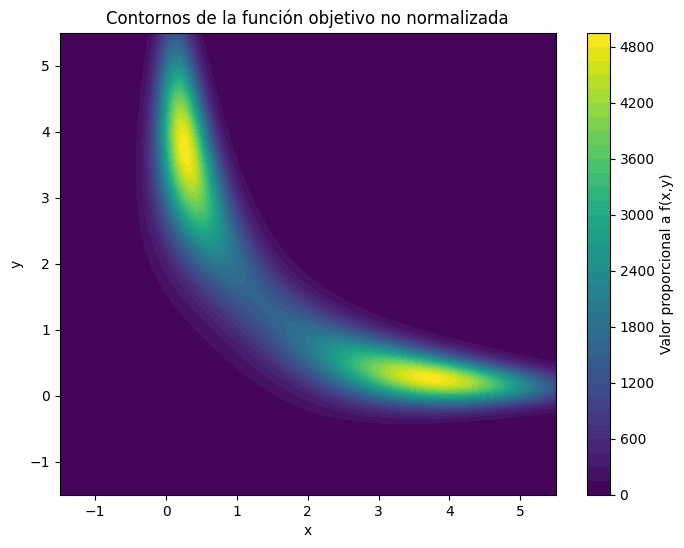

In [3]:
x_grid = np.linspace(-1.5, 5.5, 300)
y_grid = np.linspace(-1.5, 5.5, 300)

X, Y = np.meshgrid(x_grid, y_grid)
Z = pi_no_normalizada(X, Y)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=35)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Contornos de la función objetivo no normalizada")
plt.colorbar(label="Valor proporcional a f(x,y)")
plt.show()

## 4. Formulación del algoritmo de Metropolis

Sea el estado actual de la cadena
$$X_t=(x_t,y_t)$$

Usaremos una **propuesta de caminata aleatoria gaussiana**:
$$Y=X_t+\varepsilon\qquad\varepsilon\sim N_2(0,\sigma^2 I)$$

Como esta propuesta es simétrica,
$$q(Y\mid X_t)=q(X_t\mid Y)$$

la probabilidad de aceptación del algoritmo de Metropolis se reduce a
$$\boxed{\alpha(X_t,Y)=\min\left\{1,\frac{\pi(Y)}{\pi(X_t)}\right\}}$$

Trabajaremos con logaritmos para mayor estabilidad numérica.

In [4]:
def metropolis_2d(n_iter=60000, x0=(1.0, 1.0), sigma=0.8, seed=12345):

    rng = np.random.default_rng(seed)   # Generador de números pseudoaleatorios reproducible
    cadena = np.zeros((n_iter, 2))

    actual = np.array(x0, dtype=float)  # Estado inicial

    # Logaritmo de la función objetivo en el estado actual
    log_pi_actual = log_pi(actual[0], actual[1])

    aceptados = 0

    for i in range(n_iter):

        candidato = actual + rng.normal(0.0, sigma, size=2)   #Generar un candidato mediante caminata aleatoria gaussiana
        log_pi_candidato = log_pi(candidato[0], candidato[1]) #Evaluar el candidato
        log_r = log_pi_candidato - log_pi_actual              #Logaritmo del cociente de aceptación

        if np.log(rng.random()) < min(0.0, log_r):             #Regla de aceptación de Metropolis
            actual = candidato
            log_pi_actual = log_pi_candidato
            aceptados += 1

        cadena[i] = actual

    tasa_aceptacion = aceptados / n_iter

    return cadena, tasa_aceptacion

## 6. Ejecución del algoritmo

Se toma como estado inicial

$$X_0=(1,1)$$

y una desviación de propuesta
$$\sigma=0.8$$

Se generan $$60\,000$$ iteraciones.


In [5]:
n_iter = 60000
sigma_propuesta = 0.8
estado_inicial = (1.0, 1.0)

cadena, tasa_aceptacion = metropolis_2d(
    n_iter=n_iter,
    x0=estado_inicial,
    sigma=sigma_propuesta,
    seed=12345
)

print(f"Número de iteraciones: {n_iter}")
print(f"Tasa de aceptación: {tasa_aceptacion:.4f}")

Número de iteraciones: 60000
Tasa de aceptación: 0.3682


In [6]:
burn = 10000

muestra = cadena[burn:]

x_muestra = muestra[:, 0]
y_muestra = muestra[:, 1]

print("Iteraciones descartadas:", burn)
print("Tamaño de la muestra final:", len(muestra))

Iteraciones descartadas: 10000
Tamaño de la muestra final: 50000


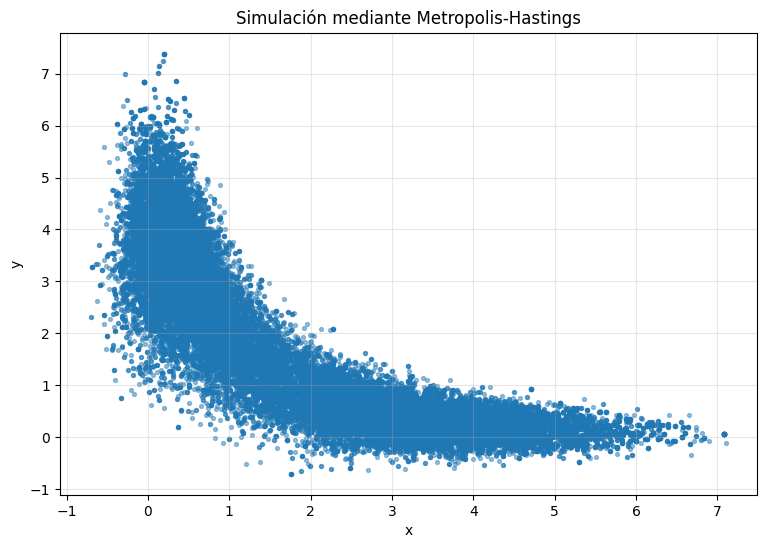

In [7]:
plt.figure(figsize=(9, 6))
plt.scatter(
    cadena[burn:, 0],
    cadena[burn:, 1],
    s=8,
    alpha=0.45
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Simulación mediante Metropolis-Hastings")
plt.grid(alpha=0.3)
plt.show()




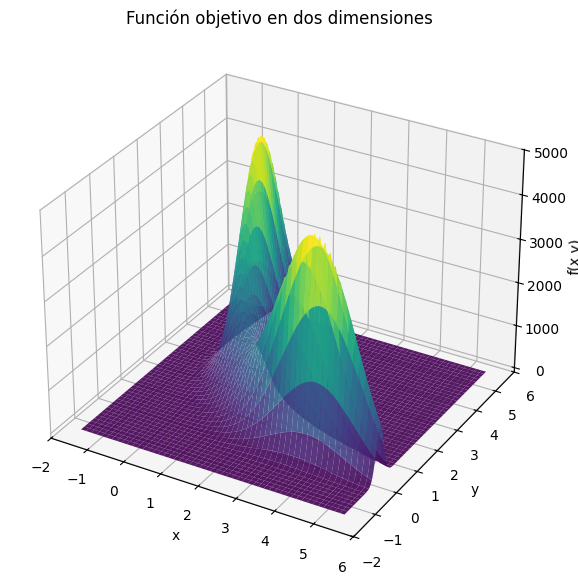

In [8]:

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    edgecolor="none",
    alpha=0.9
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")
ax.set_title("Función objetivo en dos dimensiones")

plt.show()

## 8. Trayectoria de la coordenada \(x\)

Esta gráfica muestra cómo evoluciona la primera coordenada de la cadena a lo largo de las iteraciones.

La línea vertical indica dónde termina el *burn-in*.

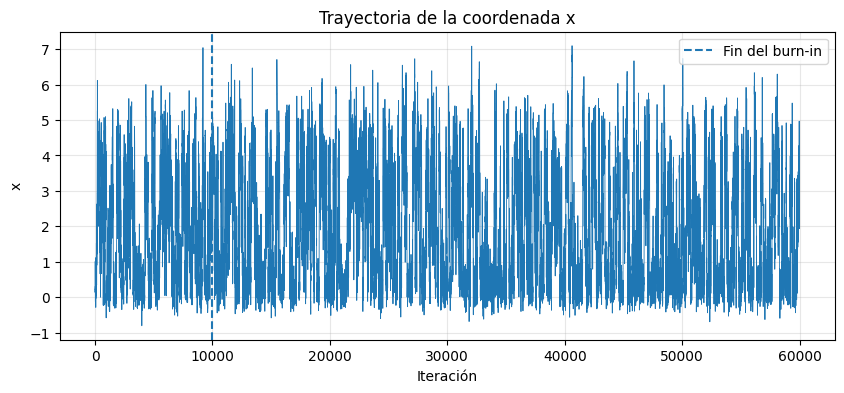

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(cadena[:, 0], linewidth=0.6)
plt.axvline(burn, linestyle="--", label="Fin del burn-in")
plt.xlabel("Iteración")
plt.ylabel("x")
plt.title("Trayectoria de la coordenada x")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. Trayectoria de la coordenada \(y\)

Se realiza el mismo diagnóstico para la segunda coordenada.

La distribución objetivo es simétrica al intercambiar $x$ y $y$, por lo que ambas coordenadas deben mostrar comportamientos análogos.

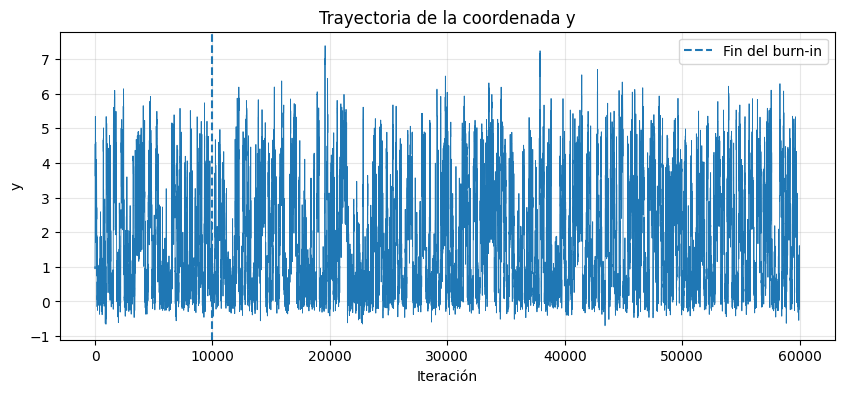

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(cadena[:, 1], linewidth=0.6)
plt.axvline(burn, linestyle="--", label="Fin del burn-in")
plt.xlabel("Iteración")
plt.ylabel("y")
plt.title("Trayectoria de la coordenada y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Muestra generada sobre los contornos de la función

Superponemos una parte de los puntos producidos por Metropolis sobre los contornos de la función objetivo.

Si el algoritmo funciona correctamente, los puntos deben concentrarse precisamente donde la función tiene mayor valor.

In [11]:
# Cálculo numérico de las densidades marginales teóricas
# a partir de la función bidimensional principal.

# Integral respecto de y para obtener f_X(x)
fx_marginal = np.trapz(Z, y_grid, axis=0)

# Integral respecto de x para obtener f_Y(y)
fy_marginal = np.trapz(Z, x_grid, axis=1)

# Normalización numérica para que ambas sean densidades
fx_marginal = fx_marginal / np.trapz(fx_marginal, x_grid)
fy_marginal = fy_marginal / np.trapz(fy_marginal, y_grid)

/tmp/ipykernel_18308/2950158261.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  fx_marginal = np.trapz(Z, y_grid, axis=0)
/tmp/ipykernel_18308/2950158261.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  fy_marginal = np.trapz(Z, x_grid, axis=1)
/tmp/ipykernel_18308/2950158261.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  fx_marginal = fx_marginal / np.trapz(fx_marginal, x_grid)
/tmp/ipykernel_18308/2950158261.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  fy_marginal = fy_marginal / np.trapz(fy_marginal, y_grid)


## 11. Histograma marginal de \(X\)

El histograma de \(X\) muestra con qué frecuencia la cadena visita distintos valores de la primera coordenada.

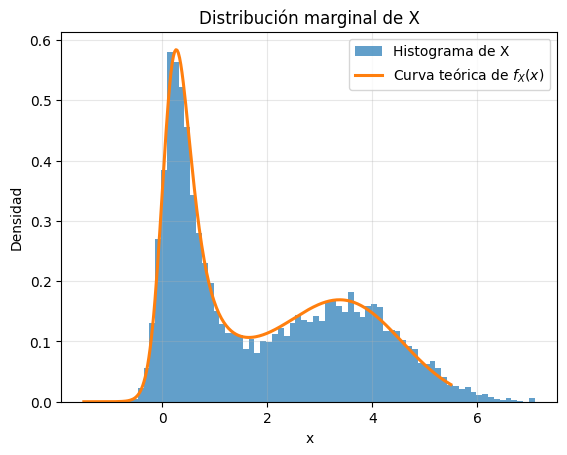

In [12]:

# Histograma empírico normalizado
plt.hist(x_muestra, bins=70, density=True, alpha=0.7, label="Histograma de X")

# Curva teórica marginal obtenida de la función principal
plt.plot(x_grid, fx_marginal, linewidth=2.2, label="Curva teórica de $f_X(x)$")

plt.xlabel("x")
plt.ylabel("Densidad")
plt.title("Distribución marginal de X")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 12. Histograma marginal de \(Y\)

Se construye el histograma correspondiente a la segunda coordenada.

Debido a la simetría

\[
f(x,y)=f(y,x),
\]

las distribuciones marginales de \(X\) y \(Y\) deben ser aproximadamente iguales.

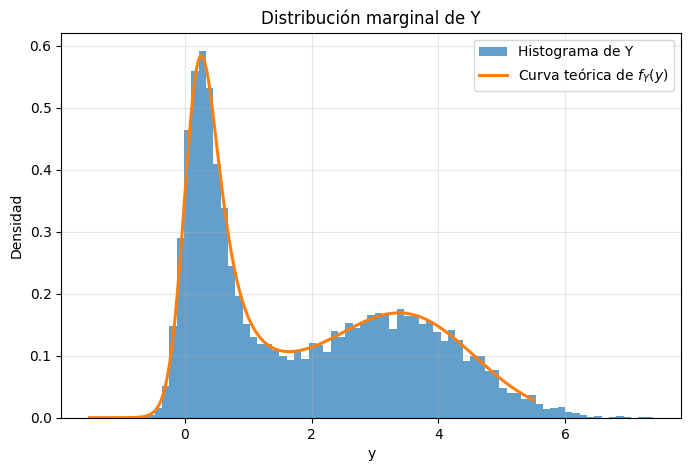

In [13]:
plt.figure(figsize=(8, 5))

# Histograma empírico normalizado
plt.hist(y_muestra, bins=70, density=True, alpha=0.7, label="Histograma de Y")

# Curva teórica marginal obtenida de la función principal
plt.plot(y_grid, fy_marginal, linewidth=2.2, label="Curva teórica de $f_Y(y)$")

plt.xlabel("y")
plt.ylabel("Densidad")
plt.title("Distribución marginal de Y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 13. Valores medios y matriz de covarianza

Después del *burn-in* calculamos

$$
\bar x=\frac{1}{N}\sum_{i=1}^{N}x_i,
\qquad
\bar y=\frac{1}{N}\sum_{i=1}^{N}y_i,
$$

además de la matriz de covarianza.



In [14]:
media = np.mean(muestra, axis=0)
covarianza = np.cov(muestra, rowvar=False)

print("Media estimada de X:", media[0])
print("Media estimada de Y:", media[1])

print("\nMatriz de covarianza estimada:")
print(covarianza)

Media estimada de X: 1.9072027097393012
Media estimada de Y: 1.8504089651936624

Matriz de covarianza estimada:
[[ 2.94832973 -2.40305243]
 [-2.40305243  2.77341341]]


## 14. Verificación de la estructura bimodal

La función objetivo tiene dos regiones principales de alta probabilidad.

Para comprobar que la cadena explora ambas, calculamos qué proporción de la muestra satisface $$x>y$$ y qué proporción satisface $$x<y$$.

Por la simetría de la función, ambas proporciones deben ser cercanas a $1/2$.

In [15]:
proporcion_x_mayor_y = np.mean(x_muestra > y_muestra)
proporcion_x_menor_y = np.mean(x_muestra < y_muestra)

print(f"Proporción con x > y: {proporcion_x_mayor_y:.4f}")
print(f"Proporción con x < y: {proporcion_x_menor_y:.4f}")

Proporción con x > y: 0.5006
Proporción con x < y: 0.4994


## 15. Localización analítica de las dos modas

Como
$$f(x,y)\propto e^{-H(x,y)/2}$$

maximizar $f$ equivale a minimizar $H$.

Las condiciones de primer orden son
$$\frac{\partial H}{\partial x}=2x(y^2+1)-8=0$$


$$\frac{\partial H}{\partial y}=2y(x^2+1)-8=0$$

Dos mínimos globales de $H$, y por tanto máximos de $f$, son
$$\boxed{(2+\sqrt{3},\,2-\sqrt{3})}$$

y
$$\boxed{(2-\sqrt{3},\,2+\sqrt{3})}$$

Numéricamente:
$$(3.7321,0.2679)\qquad\text{y}\qquad(0.2679,3.7321)$$

Primera moda: [3.73205081 0.26794919]
Segunda moda: [0.26794919 3.73205081]


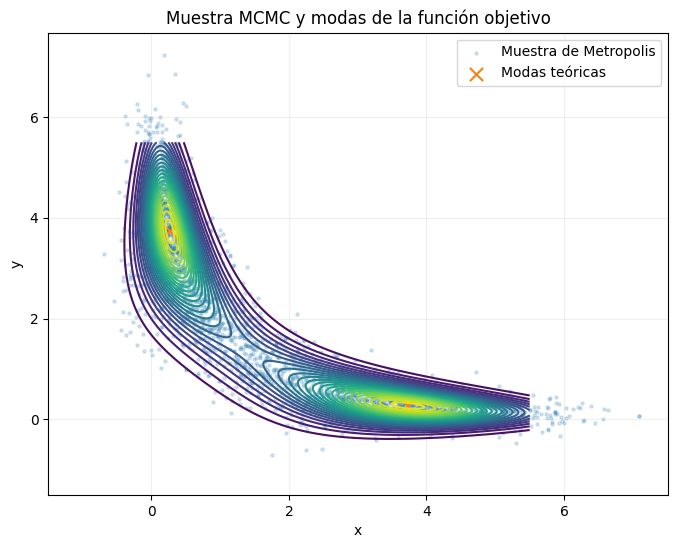

In [16]:
modo_1 = np.array([2 + np.sqrt(3), 2 - np.sqrt(3)])
modo_2 = np.array([2 - np.sqrt(3), 2 + np.sqrt(3)])

print("Primera moda:", modo_1)
print("Segunda moda:", modo_2)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=25)

plt.scatter(
    x_muestra[::15],
    y_muestra[::15],
    s=5,
    alpha=0.18,
    label="Muestra de Metropolis"
)

plt.scatter(
    [modo_1[0], modo_2[0]],
    [modo_1[1], modo_2[1]],
    s=90,
    marker="x",
    label="Modas teóricas"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Muestra MCMC y modas de la función objetivo")
plt.legend()
plt.grid(alpha=0.2)
plt.show()